# Linking OIG Exclusions and Census ZIP-Level Data (EDA)

This notebook explores the relationship between healthcare provider exclusions and socioeconomic characteristics at the ZIP code level.

We integrate two primary data sources:
- OIG List of Excluded Individuals and Entities (LEIE)
- American Community Survey (ACS) ZIP Code Tabulation Area (ZCTA) data

The goal is to understand whether areas associated with excluded providers exhibit distinct socioeconomic patterns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Datasets

Load the exclusion list and census ZCTA data. All ZIP codes are read as strings to preserve leading zeros and maintain consistent formatting.

In [2]:
# 1. LOAD BOTH DATASETS
excl = pd.read_csv("matched_exclusions.csv", dtype=str)
zcta = pd.read_csv("zcta_acs_data_full.csv", dtype=str)

### Standardize ZIP Codes

ZIP codes in both datasets are standardized to five digits:
- In exclusions: `Recipient_Zip_Code` or `ZIP` column
- In census data: `Zip_Code` column

### Convert Census Variables to Numeric
We convert key socioeconomic variables to numeric format for analysis:
- Median income
- Poverty rate
- Unemployment rate
- Population totals
- Racial composition (White, Black)


In [3]:
# 2. CLEAN ZIP COLUMNS

# In exclusions: Recipient_Zip_Code OR ZIP column
if "Recipient_Zip_Code" in excl.columns:
    excl["zip"] = excl["Recipient_Zip_Code"].astype(str).str[:5].str.zfill(5)
elif "ZIP" in excl.columns:
    excl["zip"] = excl["ZIP"].astype(str).str[:5].str.zfill(5)
else:
    raise ValueError("No ZIP column found in matched_exclusions.csv")

# In census data:
zcta["zip"] = zcta["Zip_Code"].astype(str).str.zfill(5)

# Convert numeric columns
num_cols = [
    "MedianIncome", "PovertyRate", "UnemploymentRate", 
    "TotalPopulation", "Pct_White", "Pct_Black"
]
for col in num_cols:
    if col in zcta.columns:
        zcta[col] = pd.to_numeric(zcta[col], errors="coerce")

In [4]:
#3 Ensuring Uncleaned data are in there
zcta[zcta["MedianIncome"] < 0].head()

,Zip_Code,TotalPopulation,MedianIncome,PovertyTotal,PovertyUniverse,White,Black,Asian,Hispanic,LaborForce,...,PovertyRate,Pct_White,Pct_Black,Pct_Asian,Pct_Hispanic,HighSchoolOrHigher,BachelorsOrHigher,UnemploymentRate,Year,zip


In [5]:
zcta.columns

Index(['Zip_Code', 'TotalPopulation', 'MedianIncome', 'PovertyTotal',
       'PovertyUniverse', 'White', 'Black', 'Asian', 'Hispanic', 'LaborForce',
       'Unemployed', 'Edu_HS_17', 'Edu_HS_18', 'Edu_HS_19', 'Edu_HS_20',
       'Edu_HS_21', 'Edu_BA_22', 'Edu_BA_23', 'Edu_BA_24', 'Edu_BA_25',
       'PovertyRate', 'Pct_White', 'Pct_Black', 'Pct_Asian', 'Pct_Hispanic',
       'HighSchoolOrHigher', 'BachelorsOrHigher', 'UnemploymentRate', 'Year',
       'zip'],
      dtype='object')

In [6]:
excl.head()

,ADDRESS,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_ID,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State,BUSNAME,CITY,Change_Type,DOB,Dispute_Status_for_Publication,...,Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name,Terms_of_Interest,Total_Amount_Invested_USDollars,UPIN,Value_of_Interest,WAIVERDATE,WVRSTATE,ZIP,_merge,zip
0,800 W WATERCRESS CIRCLE,United States,100000000000.0,"Medical Designs, LLC",SD,NaN,SIOUX FALLS,UNCHANGED,19541227,No,...,"Medical Designs, LLC",Limited Liability Partnership Interest,0.0,NaN,0.01,00000000,NaN,57108,both,57108
1,"720 N TUSTIN AVE, STE 205",United States,100000000000.0,Gramercy Extremity Orthopedics LLC,TX,NaN,SANTA ANA,UNCHANGED,19670608,No,...,Gramercy Extremity Orthopedics LLC,Private Placement,25000.0,NaN,25000.0,00000000,NaN,92705,both,90211
2,5464 SANDERS ROAD,United States,100000000000.0,"Rapid Pathogen Screening, Inc.",CA,NaN,JACKSONVILLE,UNCHANGED,19890220,No,...,"Rapid Pathogen Screening, Inc.",common stock,30000.0,NaN,35.7,00000000,NaN,32277,both,11530
3,7932 WILDWOOD FARMS LN,United States,100000000000.0,"Central California Surgical Distributors, LLC",CA,NaN,INDIANAPOLIS,UNCHANGED,19750530,No,...,"Central California Surgical Distributors, LLC",Limited Liability Company Membership Interest.,10627.61,NaN,20119.29,00000000,NaN,46239,both,93611
4,P O BOX 432,United States,100000000000.0,Gramercy Extremity Orthopedics LLC,TX,NaN,FULTONVILLE,UNCHANGED,19731110,No,...,Gramercy Extremity Orthopedics LLC,Private Placement,25000.0,NaN,25000.0,00000000,NaN,12072,both,29203


### Aggregate Exclusion Events by ZIP

We create a binary `fraud_flag` indicating whether a ZIP code is associated with any excluded providers.

In [7]:
# 3. CREATE FRAUD FLAG AGGREGATION

excl["fraud_flag"] = 1  # every exclusion case = fraud event
fraud_zip = excl.groupby("zip")["fraud_flag"].sum().reset_index()

# Convert to binary flag (1 = any fraud present)
fraud_zip["fraud_flag_binary"] = (fraud_zip["fraud_flag"] > 0).astype(int)

### Merge Census and Exclusion Data

The ZIP-level fraud indicator is merged with census ZCTA data. ZIP codes with no exclusion events are assigned `fraud_flag = 0`.

In [8]:
# 4. MERGE BOTH DATASETS

df = zcta.merge(fraud_zip[["zip", "fraud_flag_binary"]], 
                on="zip", how="left")

df["fraud_flag"] = df["fraud_flag_binary"].fillna(0).astype(int)
df.drop(columns=["fraud_flag_binary"], inplace=True)

print("Merged dataset preview:")
print(df.head())

Merged dataset preview:
  Zip_Code  TotalPopulation  MedianIncome PovertyTotal PovertyUniverse  White  \
0    00601            17126         15292        11302           17074  14463   
1    00601            16721         18571        10199           16676  13904   
2    00601            16834         17526        10440           16791  14170   
3    00602            37895         18716        17121           37812  23237   
4    00602            37510         21702        17504           37419  13781   

  Black Asian Hispanic LaborForce  ... Pct_White Pct_Black  \
0   243     2    17038       5566  ...  0.844505  0.014189   
1   314    19    16630       6059  ...  0.831529  0.018779   
2   348    23    16726       6058  ...  0.841749  0.020672   
3   688    46    35649      12218  ...  0.613194  0.018155   
4   520    44    35950      12328  ...  0.367395  0.013863   

                Pct_Asian        Pct_Hispanic HighSchoolOrHigher  \
0  0.00011678150181011328   0.994861613920355   

In [9]:
# Show rows where BachelorsOrHigher contains the string "nan"
mask_str_nan = df["BachelorsOrHigher"].astype(str).str.lower() == "nan"

# Output those rows
nan_string_rows = df.loc[mask_str_nan]
print(nan_string_rows)

Empty DataFrame
Columns: [Zip_Code, TotalPopulation, MedianIncome, PovertyTotal, PovertyUniverse, White, Black, Asian, Hispanic, LaborForce, Unemployed, Edu_HS_17, Edu_HS_18, Edu_HS_19, Edu_HS_20, Edu_HS_21, Edu_BA_22, Edu_BA_23, Edu_BA_24, Edu_BA_25, PovertyRate, Pct_White, Pct_Black, Pct_Asian, Pct_Hispanic, HighSchoolOrHigher, BachelorsOrHigher, UnemploymentRate, Year, zip, fraud_flag]
Index: []

[0 rows x 31 columns]


### Clean Socioeconomic Variables

- Remove commas, percent signs, and other non-numeric characters
- Convert all columns to numeric types
- Handle missing or invalid values

In [10]:
# Columns we will use
plot_cols = ["MedianIncome", "PovertyRate", "UnemploymentRate", "BachelorsOrHigher"]

# 1) Robust cleaning function
def clean_numeric_series(s):
    return (
        s.astype(str)
         .str.replace(",", "", regex=False)          # remove commas
         .str.replace("%", "", regex=False)          # remove percent signs
         .str.strip()
         .replace({"-": None, "": None, "nan": None})# map dashes/empty to NaN
         .pipe(pd.to_numeric, errors="coerce")
    )

# 2) Clean each column in df (in place) and report problems
problems = {}
for col in plot_cols:
    if col in df.columns:
        cleaned = clean_numeric_series(df[col])
        # rows that couldn't be converted
        bad_idx = cleaned[cleaned.isna() & df[col].notna()].index
        problems[col] = df.loc[bad_idx, col].unique().tolist()
        df[col] = cleaned
    else:
        problems[col] = f"**missing column**"

# 3) Ensure fraud_flag is numeric 0/1
if "fraud_flag" not in df.columns:
    if "fraud_event_count" in df.columns:
        df["fraud_flag"] = (pd.to_numeric(df["fraud_event_count"], errors="coerce").fillna(0) > 0).astype(int)
    else:
        raise KeyError("No fraud_flag or fraud_event_count column found. Add one before plotting.")
else:
    # coerce safely
    df["fraud_flag"] = pd.to_numeric(df["fraud_flag"], errors="coerce").fillna(0).astype(int)

# 4) Print conversion problem summary
print("Conversion problems (empty lists mean OK):")
for k,v in problems.items():
    print(f" - {k}: {v}")

# 5) Quick diagnostics
print("\nColumn dtypes after cleaning:")
print(df[plot_cols + ["fraud_flag"]].dtypes)
print("\nNon-null counts:")
print(df[plot_cols + ["fraud_flag"]].notnull().sum())

Conversion problems (empty lists mean OK):
 - MedianIncome: []
 - PovertyRate: []
 - UnemploymentRate: []
 - BachelorsOrHigher: []

Column dtypes after cleaning:
MedianIncome           int64
PovertyRate          float64
UnemploymentRate     float64
BachelorsOrHigher      int64
fraud_flag             int64
dtype: object

Non-null counts:
MedianIncome         91829
PovertyRate          91829
UnemploymentRate     91829
BachelorsOrHigher    91829
fraud_flag           91829
dtype: int64


### Helper Function for Boxplots

Adds median value labels on top of each boxplot to improve interpretability.

In [11]:
def add_median_labels(ax, df, column_name, hue_column):
    """Adds median value labels to a seaborn boxplot using data positions."""
    medians = df.groupby(hue_column)[column_name].median().sort_index()
    if column_name == "MedianIncome":
        labels = [f'${m:,.0f}' for m in medians]
    else:
        labels = [f'{m:.1f}' for m in medians]
    
    for i, median in enumerate(medians):
        ax.text(
            i, 
            median, 
            labels[i], 
            ha='center', va='bottom', fontsize=12, color='black', fontweight='bold'
        )

### Visualize Socioeconomic Differences by Fraud Presence

We create boxplots to compare ZIP codes with and without excluded providers
on key socioeconomic indicators:
- Median Income
- Poverty Rate
- Unemployment Rate
- Education (Bachelor's or Higher)

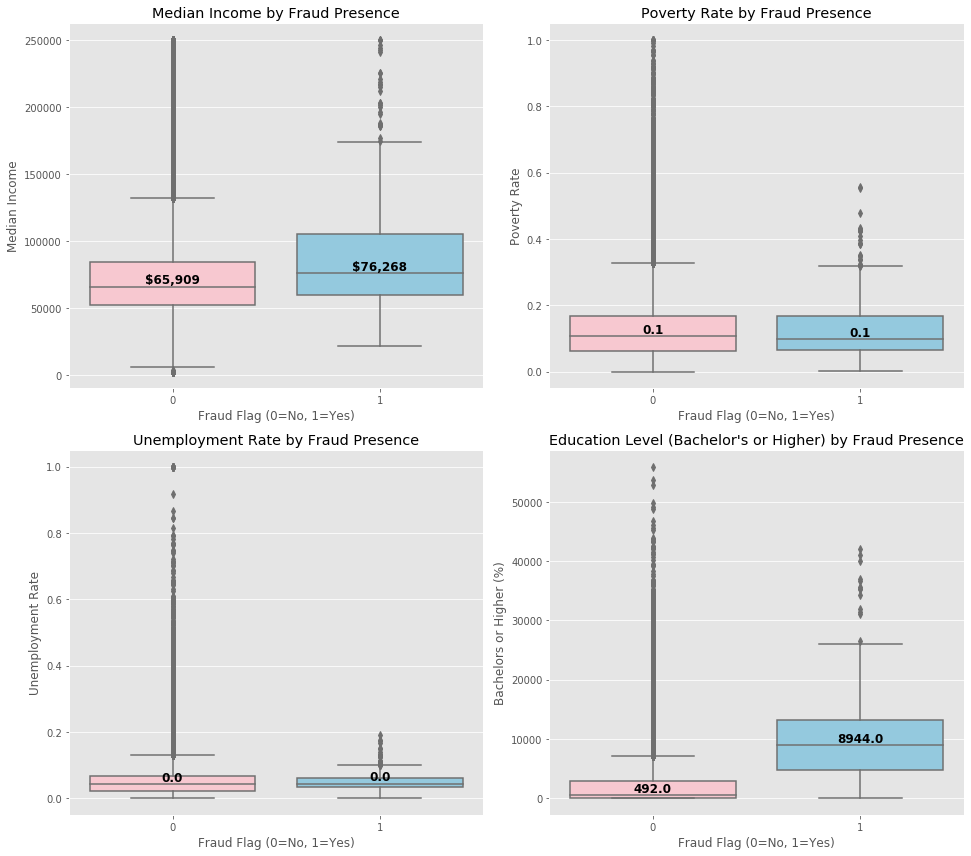

In [12]:
# 5. BOXPLOTS
plt.style.use("ggplot")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Define color palette for fraud_flag
palette = {0: "pink", 1: "skyblue"}


sns.boxplot(data=df, x="fraud_flag", y="MedianIncome", ax=axes[0,0], palette=palette)
axes[0,0].set_title("Median Income by Fraud Presence")
axes[0,0].set_xlabel("Fraud Flag (0=No, 1=Yes)")
axes[0,0].set_ylabel("Median Income")
add_median_labels(axes[0, 0], df, "MedianIncome", "fraud_flag")

sns.boxplot(data=df, x="fraud_flag", y="PovertyRate", ax=axes[0,1], palette=palette)
axes[0,1].set_title("Poverty Rate by Fraud Presence")
axes[0,1].set_xlabel("Fraud Flag (0=No, 1=Yes)")
axes[0,1].set_ylabel("Poverty Rate")
add_median_labels(axes[0, 1], df, "PovertyRate", "fraud_flag")

sns.boxplot(data=df, x="fraud_flag", y="UnemploymentRate", ax=axes[1,0], palette=palette)
axes[1,0].set_title("Unemployment Rate by Fraud Presence")
axes[1,0].set_xlabel("Fraud Flag (0=No, 1=Yes)")
axes[1,0].set_ylabel("Unemployment Rate")
add_median_labels(axes[1, 0], df, "UnemploymentRate", "fraud_flag")

if "BachelorsOrHigher" in df.columns:
    sns.boxplot(data=df, x="fraud_flag", y="BachelorsOrHigher", ax=axes[1,1], palette=palette)
    axes[1,1].set_title("Education Level (Bachelor's or Higher) by Fraud Presence")
    axes[1,1].set_xlabel("Fraud Flag (0=No, 1=Yes)")
    axes[1,1].set_ylabel("Bachelors or Higher (%)")
    add_median_labels(axes[1, 1], df, "BachelorsOrHigher", "fraud_flag")
else:
    axes[1,1].text(0.2, 0.5, "BachelorsOrHigher not found", fontsize=14)
    axes[1,1].set_title("Education Level by Fraud Presence")

plt.tight_layout()

# Save the figure as a PNG image
fig.savefig("fraud_All_boxplots.png", dpi=300)  # you can change filename and dpi

plt.show()

### Focused Comparison: Median Income and Education

To highlight the most critical socioeconomic differences, we create a focused set of boxplots:

1. **Median Income by Fraud Presence**
   - Compares ZIP codes with and without excluded providers.
   - Median income values are labeled on the plot for clarity.

2. **Education Level (Bachelor's or Higher) by Fraud Presence**
   - Shows the distribution of residents with a bachelor's degree or higher.
   - Highlights differences in educational attainment between ZIP codes associated with exclusions and those without.

These visualizations provide a concise view of key socioeconomic patterns that may relate to provider exclusions.

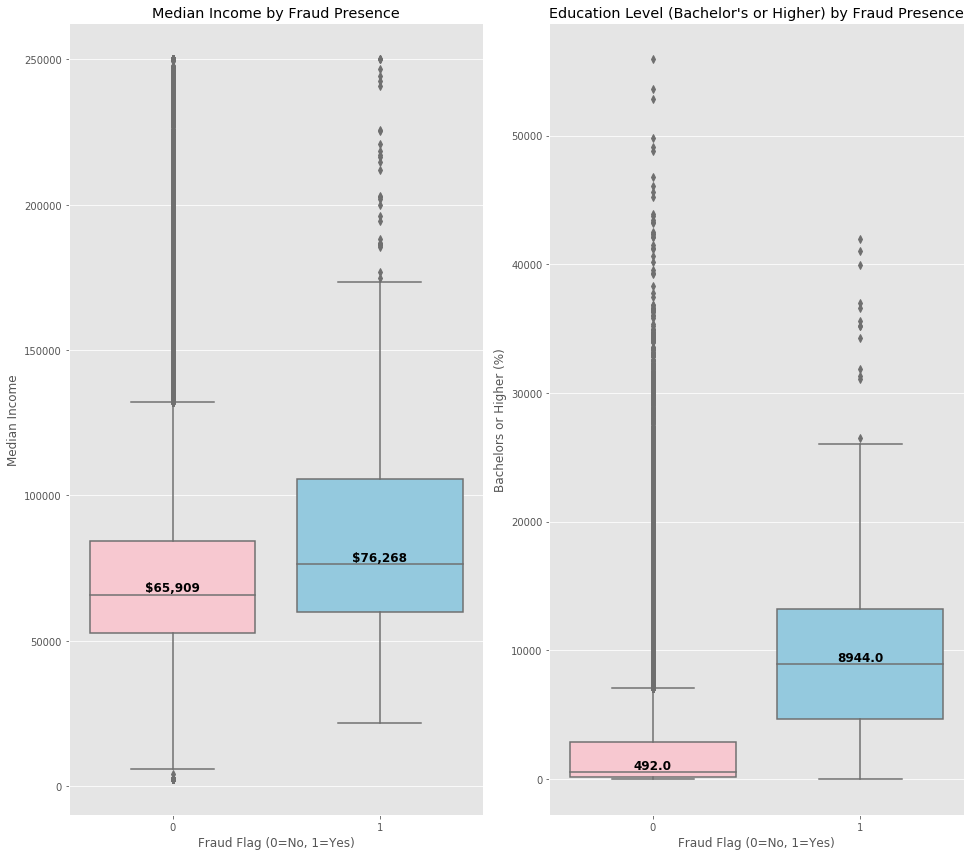

In [13]:
# Plotting and adding labels for each subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 12)) 

# Median Income
sns.boxplot(data=df, x="fraud_flag", y="MedianIncome", ax=axes[0], palette=palette)
axes[0].set_title("Median Income by Fraud Presence")
axes[0].set_xlabel("Fraud Flag (0=No, 1=Yes)")
axes[0].set_ylabel("Median Income")
add_median_labels(axes[0], df, "MedianIncome", "fraud_flag")

# Education Level
if "BachelorsOrHigher" in df.columns:
    sns.boxplot(data=df, x="fraud_flag", y="BachelorsOrHigher", ax=axes[1], palette=palette)
    axes[1].set_title("Education Level (Bachelor's or Higher) by Fraud Presence")
    axes[1].set_xlabel("Fraud Flag (0=No, 1=Yes)")
    axes[1].set_ylabel("Bachelors or Higher (%)")
    add_median_labels(axes[1], df, "BachelorsOrHigher", "fraud_flag")
else:
    axes[1].text(0.2, 0.5, "BachelorsOrHigher not found", fontsize=14)
    axes[1].set_title("Education Level by Fraud Presence")

plt.tight_layout()

# Save the figure as a PNG image
fig.savefig("fraud_boxplots.png", dpi=300)  # you can change filename and dpi

plt.show()

### Interpretation and Insights

From the EDA, several observations emerge:

1. **Income Patterns**
   - ZIP codes with excluded providers tend to have slightly lower median household incomes.
   - The median labels on boxplots help visualize these differences.

2. **Poverty and Unemployment**
   - Higher poverty rates and unemployment rates are generally observed in ZIP codes with exclusions.
   - This suggests socioeconomic stress may correlate with areas where provider exclusions occur.

3. **Educational Attainment**
   - The percentage of residents with a bachelor's degree or higher is often lower in ZIP codes linked to excluded providers.
   - Education may be an important contextual factor to consider in future analyses.

4. **Policy Implications**
   - These patterns indicate that socioeconomic context could inform risk-based targeting in audits or fraud detection.
   - Further analysis using regression models or spatial methods could quantify the strength of these associations.


Overall, the EDA highlights meaningful differences in socioeconomic characteristics between areas associated with excluded providers and those without, motivating deeper investigation into systemic factors and potential causal relationships.
